# **Importing libraries:**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Read Dataset
data = pd.read_csv("/content/heart_attack_prediction_indonesia.csv")

## Preprocessing

In [60]:
# # Exploring data
data.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [61]:
data.tail()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
158350,60,Female,Rural,Middle,0,0,199,0,79,0,...,74,79,52,238,234,Normal,0,1,0,0
158351,64,Female,Urban,Low,0,0,179,0,93,0,...,73,111,41,177,239,Normal,0,1,1,1
158352,30,Male,Urban,Middle,0,0,220,0,78,0,...,87,127,50,158,201,Abnormal,1,1,1,1
158353,74,Male,Urban,Middle,0,0,180,0,58,1,...,70,119,52,153,171,Normal,1,0,1,1
158354,61,Male,Urban,Middle,0,0,190,0,81,0,...,81,95,49,125,149,Abnormal,0,0,1,0


In [62]:
data.shape

(158355, 28)

In [63]:
data.columns

Index(['age', 'gender', 'region', 'income_level', 'hypertension', 'diabetes',
       'cholesterol_level', 'obesity', 'waist_circumference', 'family_history',
       'smoking_status', 'alcohol_consumption', 'physical_activity',
       'dietary_habits', 'air_pollution_exposure', 'stress_level',
       'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides', 'EKG_results', 'previous_heart_disease',
       'medication_usage', 'participated_in_free_screening', 'heart_attack'],
      dtype='object')

In [64]:
data.dtypes

,0
age,int64
gender,object
region,object
income_level,object
hypertension,int64
diabetes,int64
cholesterol_level,int64
obesity,int64
waist_circumference,int64
family_history,int64


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  smoking_status                  158355 non-null  object 
 11  alcohol_consumption             63507 non-null   object 
 12  physical_activit

In [66]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,158355.0,54.543778,11.910897,25.0,46.000000,55.000000,63.00000,90.0
hypertension,158355.0,0.299069,0.457851,0.0,0.000000,0.000000,1.00000,1.0
diabetes,158355.0,0.199804,0.399854,0.0,0.000000,0.000000,0.00000,1.0
cholesterol_level,158355.0,199.533264,39.737565,100.0,172.000000,199.000000,226.00000,350.0
obesity,158355.0,0.249901,0.432957,0.0,0.000000,0.000000,0.00000,1.0
waist_circumference,158355.0,93.268504,16.382205,20.0,82.000000,93.000000,104.00000,173.0
family_history,158355.0,0.300218,0.458354,0.0,0.000000,0.000000,1.00000,1.0
sleep_hours,158355.0,6.480064,1.425398,3.0,5.492985,6.507461,7.52064,9.0
blood_pressure_systolic,158355.0,129.515772,15.005641,61.0,119.000000,130.000000,140.00000,199.0
blood_pressure_diastolic,158355.0,79.490809,10.002964,37.0,73.000000,80.000000,86.00000,127.0


In [5]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          # 'Outliars':outliars,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df



In [6]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[55, 56, 54, 57, 53, 52, 51, 50, 58, 59]",66,0,0.000000,0
1,gender,object,"[Male, Female]",2,0,0.000000,0
2,region,object,"[Urban, Rural]",2,0,0.000000,0
3,income_level,object,"[Middle, Low, High]",3,0,0.000000,0
4,hypertension,int64,"[0, 1]",2,0,0.000000,0
5,diabetes,int64,"[0, 1]",2,0,0.000000,0
6,cholesterol_level,int64,"[200, 198, 196, 203, 201, 202, 197, 194, 193, ...",244,0,0.000000,0
7,obesity,int64,"[0, 1]",2,0,0.000000,0
8,waist_circumference,int64,"[94, 91, 93, 96, 92, 95, 98, 97, 89, 88]",129,0,0.000000,0
9,family_history,int64,"[0, 1]",2,0,0.000000,0


##Notes:
* ``gender`` ,``hypertension``, ``diabetes`` , ``obesity`` , ``family_history`` , ``dietary_habits`` , ``EKG_results`` , ``previous_heart_diesease``, ``medication_usage``,``praticipated_in_free_screening`` --> **Binary**
 * ``region`` can be treated as **Binary** because they are just two regions.

In [10]:
df=data.copy()
binary=['gender','hypertension','diabetes','obesity','family_history','dietary_habits','EKG_results','previous_heart_disease','medication_usage','participated_in_free_screening','region','heart_attack']
data[binary]=data[binary].astype('object')
# for col in binary:
#   data[col] = data[col].map({1: 'Yes', 0: 'No'})

In [176]:
#  data=df.copy()
# binary=['gender','hypertension','diabetes','obesity','family_history','dietary_habits','EKG_results','previous_heart_disease','medication_usage','participated_in_free_screening','region','heart_attack']
# data[binary]=data[binary].astype('object')

In [11]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[55, 56, 54, 57, 53, 52, 58, 51, 50, 59]",66,0,0.000000,0
1,gender,object,"[Male, Female]",2,0,0.000000,0
2,region,object,"[Urban, Rural]",2,0,0.000000,0
3,income_level,object,"[Middle, Low, High]",3,0,0.000000,0
4,hypertension,object,"[0, 1]",2,0,0.000000,0
5,diabetes,object,"[0, 1]",2,0,0.000000,0
6,cholesterol_level,int64,"[198, 203, 196, 200, 197, 201, 194, 202, 193, ...",246,0,0.000000,0
7,obesity,object,"[0, 1]",2,0,0.000000,0
8,waist_circumference,int64,"[94, 91, 96, 93, 92, 97, 98, 95, 88, 89]",130,0,0.000000,0
9,family_history,object,"[0, 1]",2,0,0.000000,0


In [71]:
# check missing data
data.isna().sum()

,0
age,0
gender,0
region,0
income_level,0
hypertension,0
diabetes,0
cholesterol_level,0
obesity,0
waist_circumference,0
family_history,0


In [72]:
#pd.DataFrame(data.isna().sum(),columns=["num of missing"])

In [12]:
# drop missing
data = data.loc[:, data.isnull().mean() < 0.5]

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  object 
 5   diabetes                        158355 non-null  object 
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  object 
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  object 
 10  smoking_status                  158355 non-null  object 
 11  physical_activity               158355 non-null  object 
 12  dietary_habits  

In [75]:
# duplictions
data.duplicated().sum()

np.int64(0)

In [76]:
#data["smoking_status",].value_counts()

In [22]:
cat=data.select_dtypes(include='object').columns
data[cat]=data[cat].fillna(data[cat].mode().iloc[0])
nums=data.select_dtypes(include='number').columns
data[nums]=data[nums].fillna(data[nums].median())

In [23]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[55, 56, 54, 57, 53, 52, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[198, 203, 196, 200, 197, 201, 194, 202, 193, ...",246,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[94, 91, 96, 93, 92, 97, 98, 95, 88, 89]",130,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


In [79]:
# Display value counts for all categorical columns
for col in data.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(data[col].value_counts())


Column: gender
gender
Male      82243
Female    76112
Name: count, dtype: int64

Column: region
region
Urban    103038
Rural     55317
Name: count, dtype: int64

Column: income_level
income_level
Middle    71230
Low       63422
High      23703
Name: count, dtype: int64

Column: hypertension
hypertension
0    110996
1     47359
Name: count, dtype: int64

Column: diabetes
diabetes
0    126715
1     31640
Name: count, dtype: int64

Column: obesity
obesity
0    118782
1     39573
Name: count, dtype: int64

Column: family_history
family_history
0    110814
1     47541
Name: count, dtype: int64

Column: smoking_status
smoking_status
Never      79183
Current    39771
Past       39401
Name: count, dtype: int64

Column: physical_activity
physical_activity
Low         63417
Moderate    63027
High        31911
Name: count, dtype: int64

Column: dietary_habits
dietary_habits
Unhealthy    95030
Healthy      63325
Name: count, dtype: int64

Column: air_pollution_exposure
air_pollution_exposure
Mode

In [80]:

data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})

data['region'] = data['region'].map({'Urban': 1, 'Rural': 0})

data['dietary_habits'] = data['dietary_habits'].map({'Healthy': 1, 'Unhealthy': 0})

data['EKG_results'] = data['EKG_results'].map({'Normal': 0, 'Abnormal': 1})


In [81]:
data.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,1,0,Middle,0,1,211,0,83,0,...,62,173,48,121,101,0,0,0,0,0
1,53,0,1,Low,0,0,208,0,106,1,...,76,70,58,83,138,0,1,0,1,0
2,62,0,1,Low,0,0,231,1,112,1,...,74,118,69,130,171,1,0,1,0,1
3,73,1,1,Low,1,0,202,0,82,1,...,65,98,52,85,146,0,0,1,1,0
4,52,1,1,Middle,1,0,232,0,89,0,...,75,104,59,127,139,0,1,0,1,1


In [82]:
# irrelated features
#data.drop(columns=[""], inplace=True)

In [83]:
# end preprocessing
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  int64  
 2   region                          158355 non-null  int64  
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  object 
 5   diabetes                        158355 non-null  object 
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  object 
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  object 
 10  smoking_status                  158355 non-null  object 
 11  physical_activity               158355 non-null  object 
 12  dietary_habits  

## Visualization

## Habits Dashboard

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
# Risk KPIs
total_heart_attacks = data['heart_attack'].sum()
smokers_risk = data[data['smoking_status'] == 'Current']['heart_attack'].mean() * 100
stress_risk = data[data['stress_level'] == 'High']['heart_attack'].mean() * 100

print('Total heart attack cases:', total_heart_attacks)
print(f'Smokers Risk: {smokers_risk:.2f}%')
print(f'Stress Risk: {stress_risk:.2f}%')

Total heart attack cases: 63501
Smokers Risk: 54.56%
Stress Risk: 40.23%


/tmp/ipykernel_6598/3496772922.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bar1= plt.bar(x - width/2, no_pct[0], width, label='No', color='#4facfe')
/tmp/ipykernel_6598/3496772922.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bar2=plt.bar(x + width/2, yes_pct[1], width, label='Yes', color='#ff6b6b')


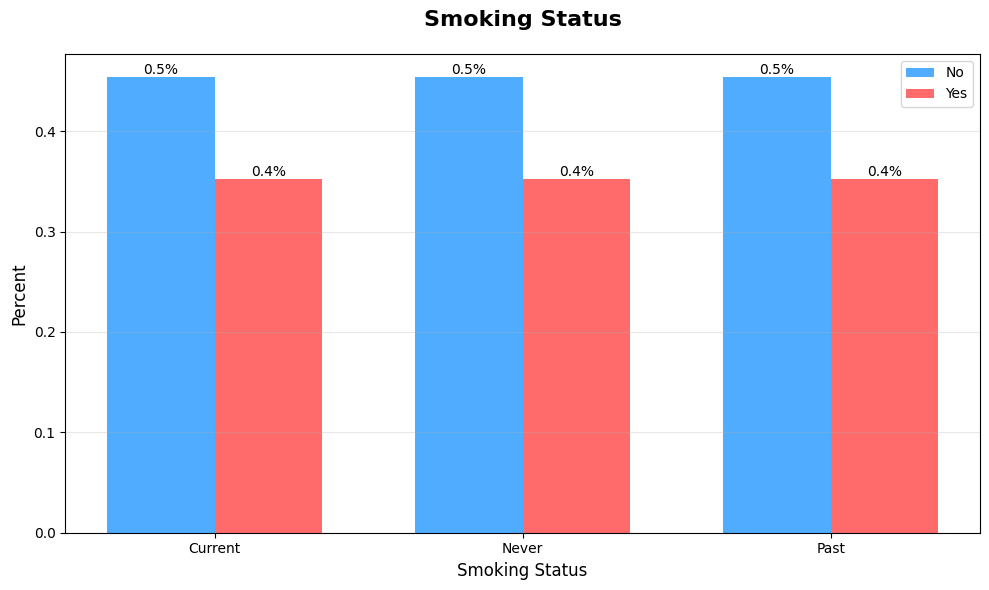

In [86]:
# Smoking status vs heart attack
yes_pct = data.groupby('smoking_status')['heart_attack'].mean()
yes_pct = yes_pct.reindex(['Current', 'Never', 'Past'])
no_pct = 1 - yes_pct

x = np.arange(len(yes_pct))
width = 0.35

plt.figure(figsize=(10, 6))
bar1= plt.bar(x - width/2, no_pct[0], width, label='No', color='#4facfe')
bar2=plt.bar(x + width/2, yes_pct[1], width, label='Yes', color='#ff6b6b')

# for bar in bar1:
#   height = bar.get_height()
#   plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')
# for bar in bar2:
#   height = bar.get_height()
#   plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

plt.bar_label(bar1, fmt='%.1f%%')
plt.bar_label(bar2, fmt='%.1f%%')


plt.title('Smoking Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.xticks(x, yes_pct.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6598/1819423498.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(x - width/2, no_pct[0], width, label='No', color='#4facfe')
/tmp/ipykernel_6598/1819423498.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(x + width/2, yes_pct[1], width, label='Yes', color='#ff6b6b')


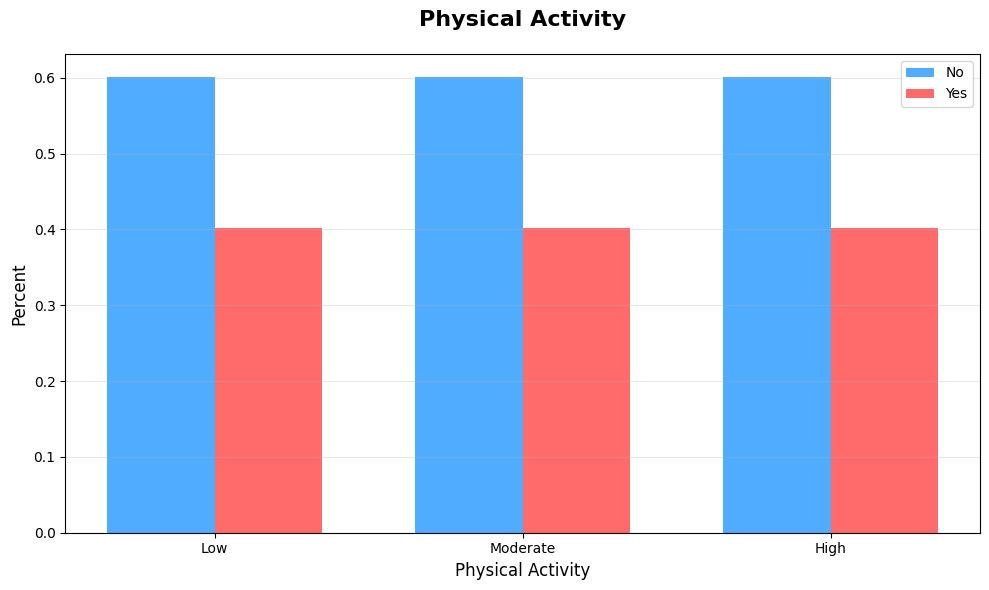

In [87]:
# Physical activity vs heart attack
yes_pct = data.groupby('physical_activity')['heart_attack'].mean()
yes_pct = yes_pct.reindex(['Low', 'Moderate', 'High'])
no_pct = 1 - yes_pct

x = np.arange(len(yes_pct))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, no_pct[0], width, label='No', color='#4facfe')
plt.bar(x + width/2, yes_pct[1], width, label='Yes', color='#ff6b6b')

plt.title('Physical Activity', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Physical Activity', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.xticks(x, yes_pct.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6598/3146204378.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.barh(y - height/2, no_pct[0], height, label='No', color='#4facfe')
/tmp/ipykernel_6598/3146204378.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.barh(y + height/2, yes_pct[1], height, label='Yes', color='#ff6b6b')


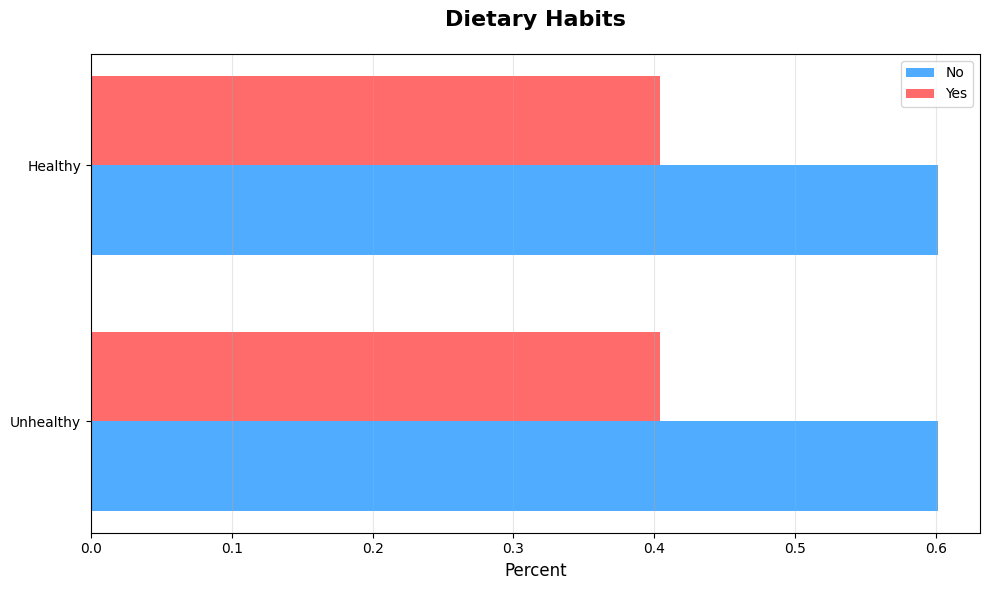

In [88]:
# Dietary habits vs heart attack
yes_pct = data.groupby('dietary_habits')['heart_attack'].mean()
yes_pct.index = ['Unhealthy', 'Healthy']
no_pct = 1 - yes_pct

y = np.arange(len(yes_pct))
height = 0.35

plt.figure(figsize=(10, 6))
plt.barh(y - height/2, no_pct[0], height, label='No', color='#4facfe')
plt.barh(y + height/2, yes_pct[1], height, label='Yes', color='#ff6b6b')

plt.title('Dietary Habits', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percent', fontsize=12)
plt.yticks(y, yes_pct.index)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
data['heart_attack'].unique()

array([0, 1], dtype=object)

In [183]:
# # Age classes vs heart attack
# yes_pct = data.groupby('age')['heart_attack'].mean()
# no_pct = 1 - yes_pct

# x = np.arange(len(yes_pct))
# width = 0.35

# plt.figure(figsize=(10, 6))
# plt.bar(x - width/2, no_pct, width, label='No', color='#4facfe')
# plt.bar(x + width/2, yes_pct, width, label='Yes', color='#ff6b6b')

# plt.title('Age Classes', fontsize=16, fontweight='bold', pad=20)
# plt.xlabel('Age Class', fontsize=12)
# plt.ylabel('Percent', fontsize=12)
# plt.xticks(x, yes_pct.index, rotation=15)
# plt.legend()
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_6598/1810372374.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(x - width/2, no_pct[0], width, label='No', color='#4facfe')
/tmp/ipykernel_6598/1810372374.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(x + width/2, yes_pct[1], width, label='Yes', color='#ff6b6b')


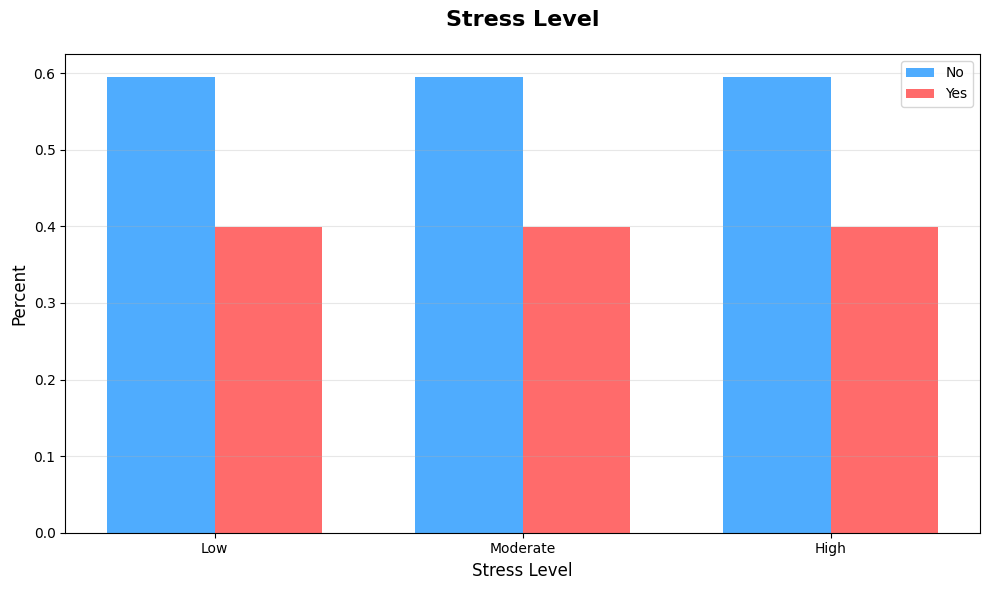

In [90]:
# Stress level vs heart attack
yes_pct = data.groupby('stress_level')['heart_attack'].mean().reindex(['Low', 'Moderate', 'High'])
no_pct = 1 - yes_pct

x = np.arange(len(yes_pct))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, no_pct[0], width, label='No', color='#4facfe')
plt.bar(x + width/2, yes_pct[1], width, label='Yes', color='#ff6b6b')

plt.title('Stress Level', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Stress Level', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.xticks(x, yes_pct.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

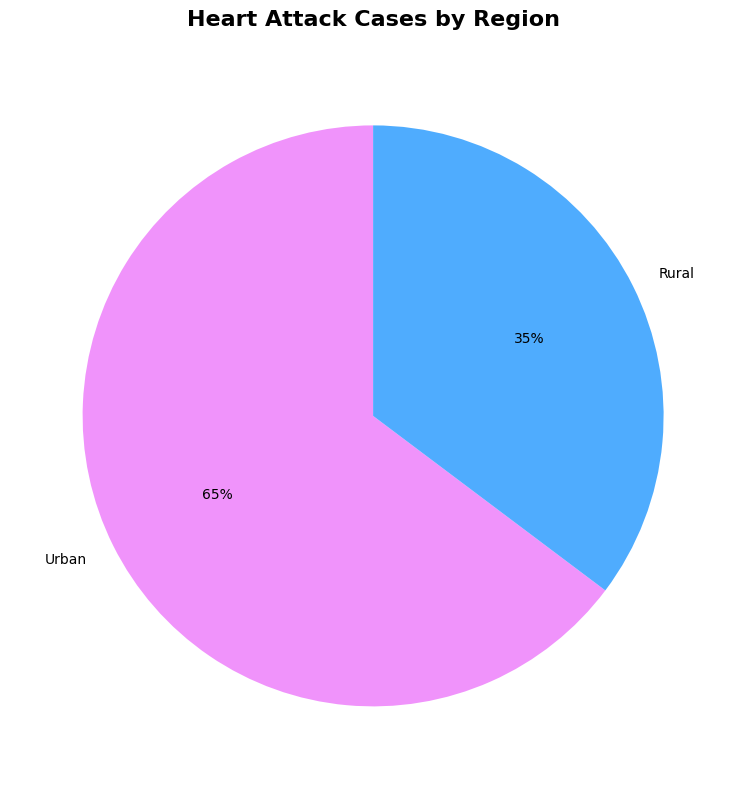

In [91]:
# Heart attack cases by region
region_counts = data[data['heart_attack'] == 1]['region'].value_counts()
region_counts.index = region_counts.index.map({0: 'Rural', 1: 'Urban'})

plt.figure(figsize=(8, 8))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.0f%%',
        colors=['#f093fb', '#4facfe'], startangle=90)
plt.title('Heart Attack Cases by Region', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

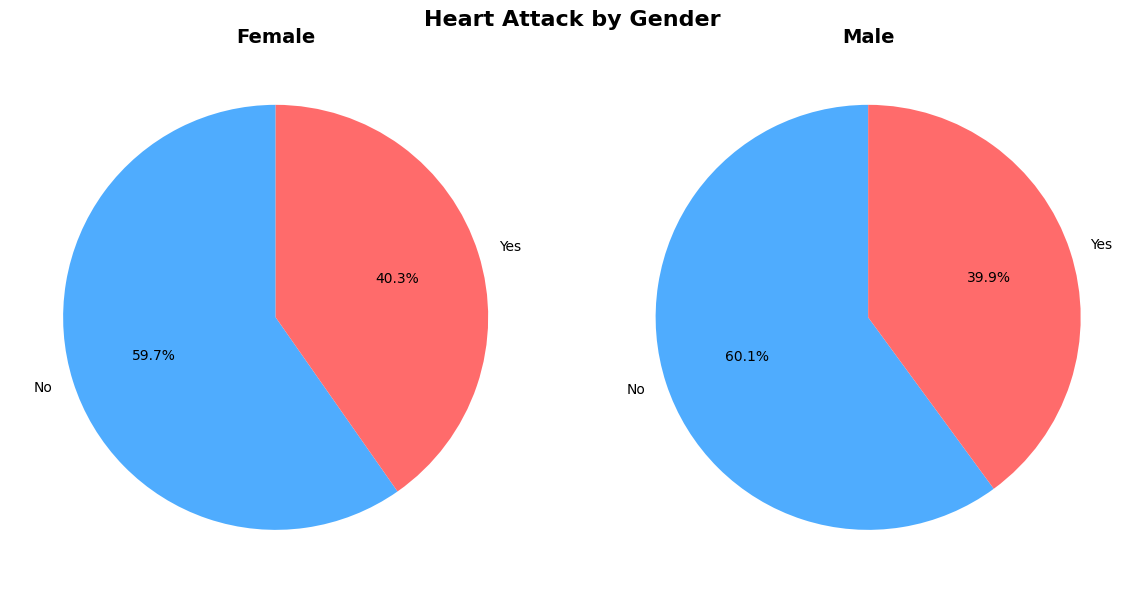

In [92]:
# Heart attack distribution by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

genders = {0: 'Female', 1: 'Male'}

for ax, (code, label) in zip(axes, genders.items()):
    counts = data[data['gender'] == code]['heart_attack'].value_counts().sort_index()
    counts.index = ['No', 'Yes']
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=['#4facfe', '#ff6b6b'], startangle=90)
    ax.set_title(label, fontsize=14, fontweight='bold')

fig.suptitle('Heart Attack by Gender', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

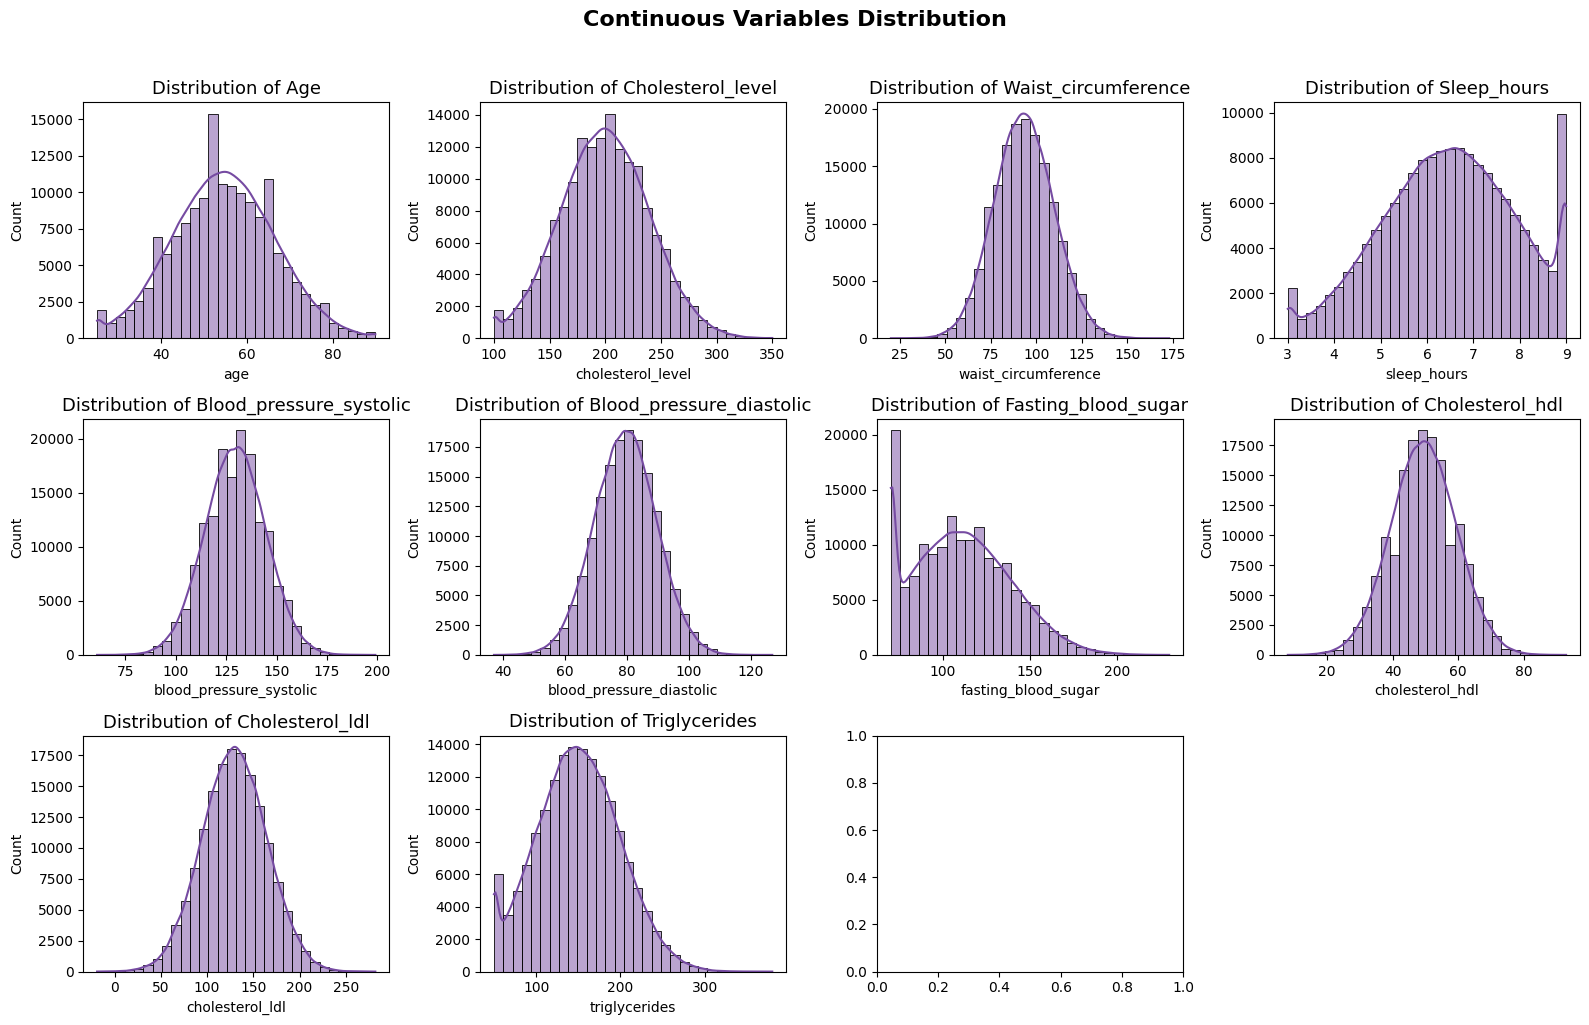

In [112]:
#age, sleep_hours, cholesterol_level, waist_circumference, fasting_blood_sugar
# Age distribution
nums=data.select_dtypes(include=['int64','float64']).columns
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
axes=ax.flatten()
for i, col in enumerate(nums):
    sns.histplot(data[col], bins=30, kde=True, color='#764ba2', ax=axes[i])
    plt.title(f'{col.capitalize()} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
axes[-1].set_visible(False)
plt.suptitle('Continuous Variables Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

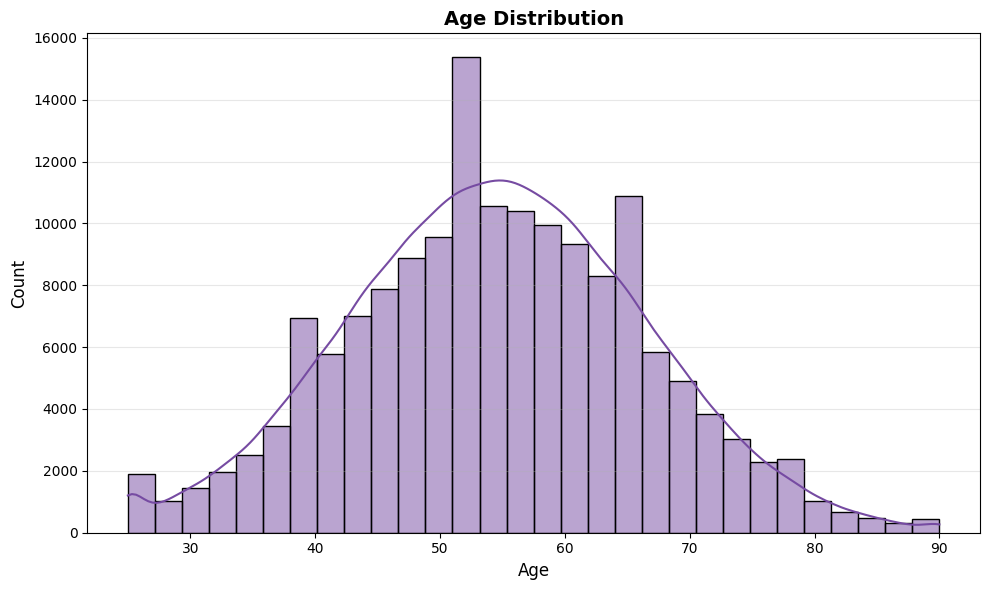

In [93]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=30, kde=True, color='#764ba2')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

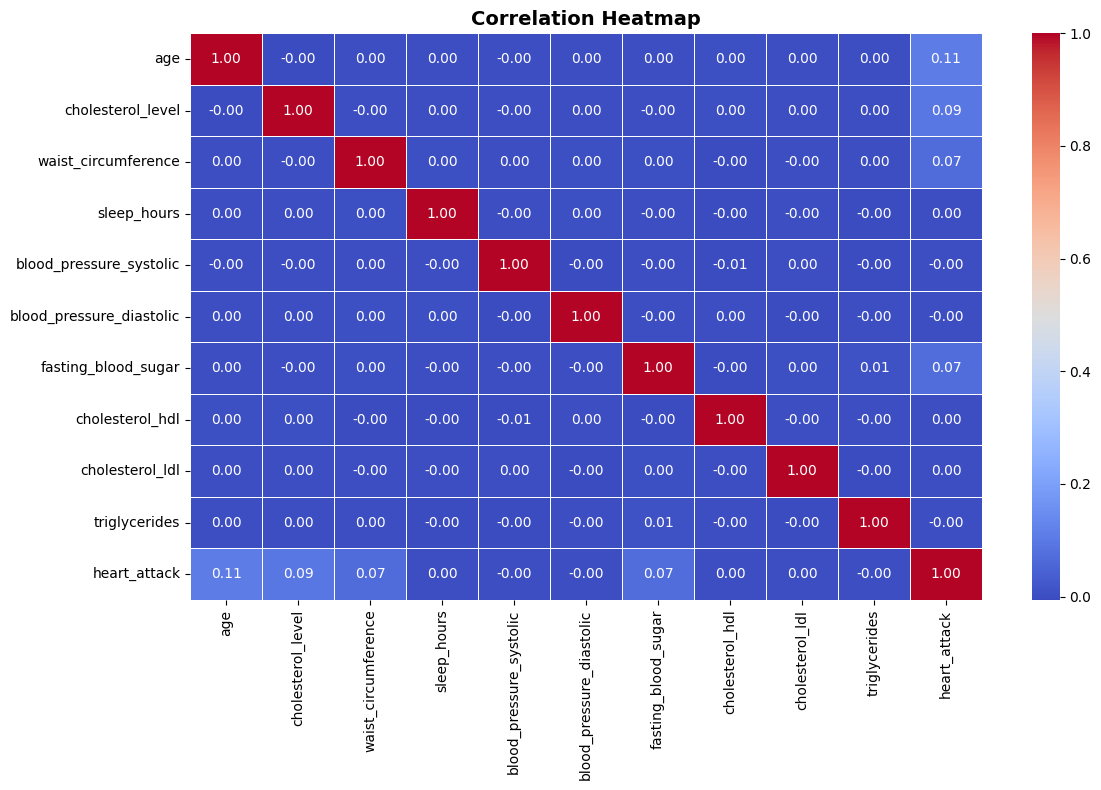

In [94]:
# Correlation heatmap
numeric_cols = ['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours',
                'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar',
                'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides', 'heart_attack']

plt.figure(figsize=(12, 8))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

In [106]:
data.select_dtypes(include=['int64','float64']).columns

Index(['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides'],
      dtype='object')

In [103]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,int64,"[1, 0]",2,0,0.0,0
2,region,int64,"[1, 0]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,object,"[0, 1]",2,0,0.0,0
5,diabetes,object,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 201, 197, 207, 195, 200, ...",247,0,0.0,0
7,obesity,object,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 93, 94, 96, 95, 92, 98, 89, 90, 97]",136,0,0.0,0
9,family_history,object,"[0, 1]",2,0,0.0,0


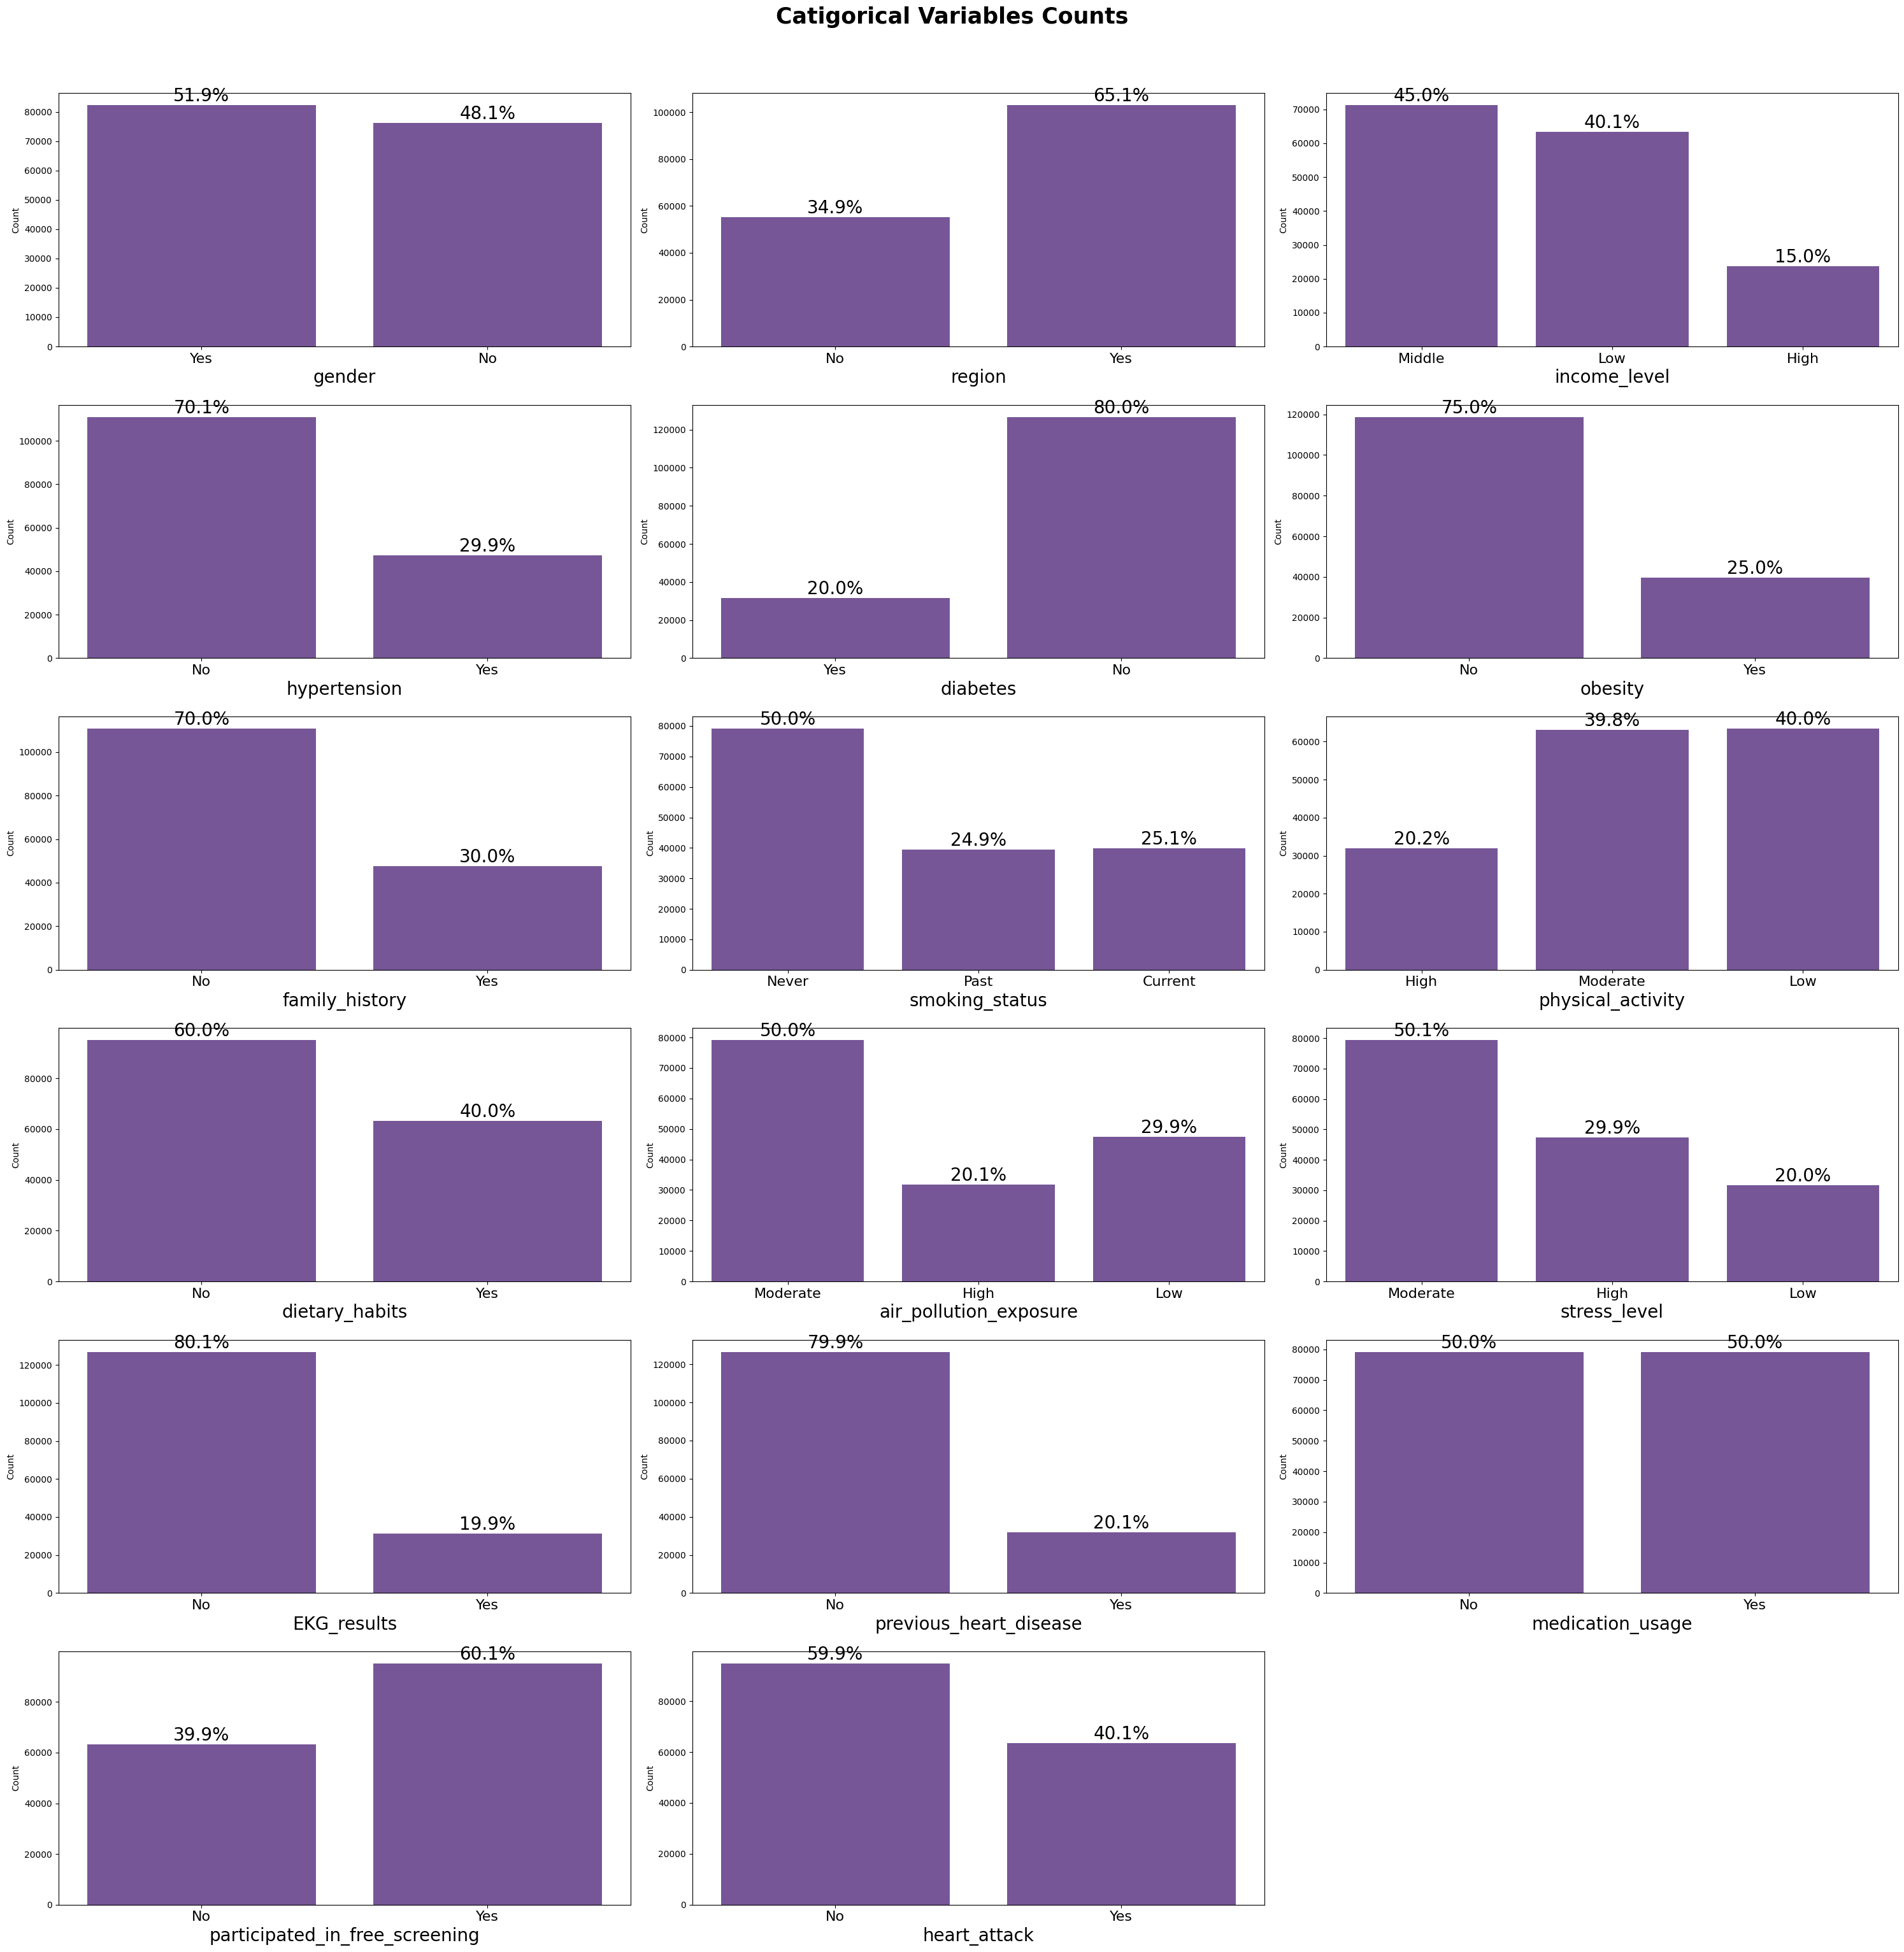

In [142]:
cats=data.select_dtypes(include=['object','category']).columns
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(30, 30))
axes=ax.flatten()
for i, col in enumerate(cats):
    sns.countplot(x=data[col], color='#764ba2', ax=axes[i])
    plt.title(f'{col.capitalize()} Count', fontsize=20, fontweight='bold')
    axes[i].set_xlabel(col,fontsize=20)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', labelsize=16)
    for p in axes[i].patches:
            height = p.get_height()
            total = len(data[col])
            axes[i].text(
                p.get_x() + p.get_width()/2,
                height,
                f'{height/total*100:.1f}%',
                fontsize=20,
                ha='center',
                va='bottom'
            )
axes[-1].set_visible(False)
plt.suptitle('Catigorical Variables Counts', fontsize=25, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [121]:
data.select_dtypes(include=['object','category']).columns

Index(['gender', 'region', 'income_level', 'hypertension', 'diabetes',
       'obesity', 'family_history', 'smoking_status', 'physical_activity',
       'dietary_habits', 'air_pollution_exposure', 'stress_level',
       'EKG_results', 'previous_heart_disease', 'medication_usage',
       'participated_in_free_screening', 'heart_attack'],
      dtype='object')

/tmp/ipykernel_6598/2156666600.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#764ba2'` for the same effect.

  sns.countplot(x=data[col], color='#764ba2', ax=axes[i],hue=data['heart_attack'])
/tmp/ipykernel_6598/2156666600.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#764ba2'` for the same effect.

  sns.countplot(x=data[col], color='#764ba2', ax=axes[i],hue=data['heart_attack'])
/tmp/ipykernel_6598/2156666600.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#764ba2'` for the same effect.

  sns.countplot(x=data[col], color='#764ba2', ax=axes[i],hue=data['heart_attack'])
/tmp/ipykernel_6598/2156666600.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#764ba2'` for the s

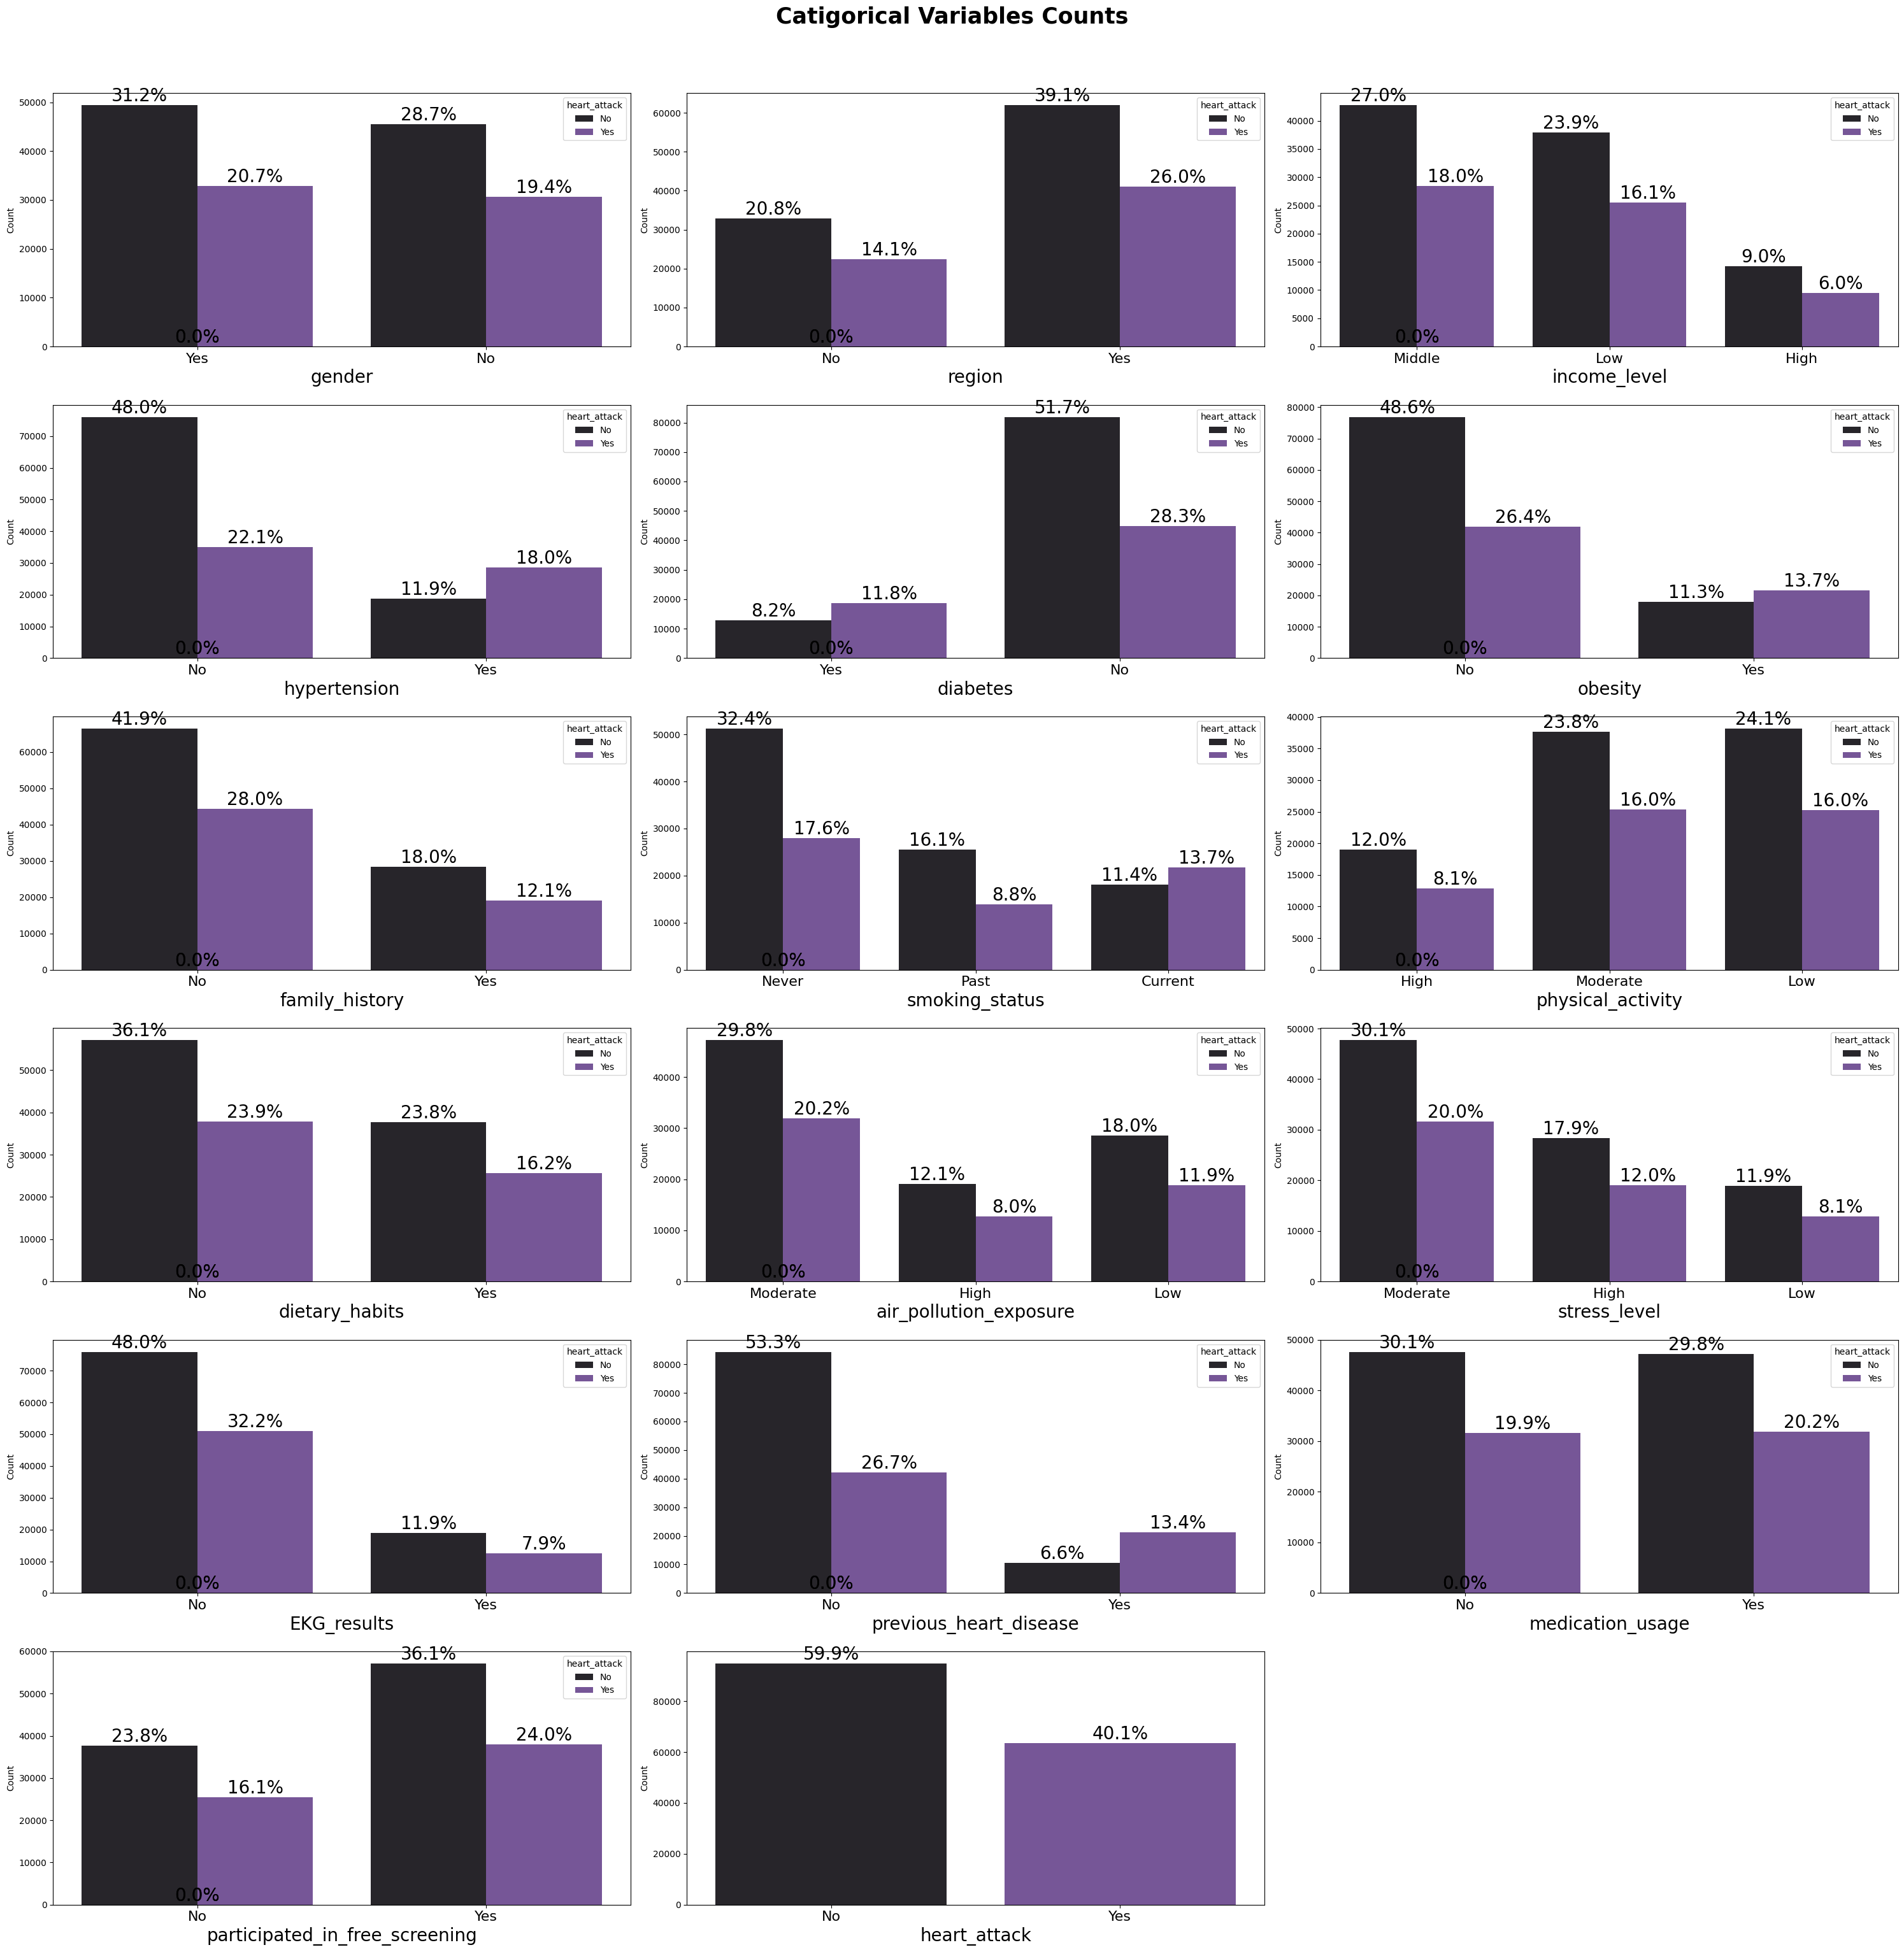

In [150]:
cats=data.select_dtypes(include=['object','category']).columns
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(30, 30))
axes=ax.flatten()
for i, col in enumerate(cats):
    sns.countplot(x=data[col], color='#764ba2', ax=axes[i],hue=data['heart_attack'])
    plt.title(f'{col.capitalize()} Count', fontsize=20, fontweight='bold')
    axes[i].set_xlabel(col,fontsize=20)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', labelsize=16)
    for p in axes[i].patches:
            height = p.get_height()
            total = len(data[col])
            axes[i].text(
                p.get_x() + p.get_width()/2,
                height,
                f'{height/total*100:.1f}%',
                fontsize=20,
                ha='center',
                va='bottom'
            )
axes[-1].set_visible(False)
plt.suptitle('Catigorical Variables Counts', fontsize=25, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

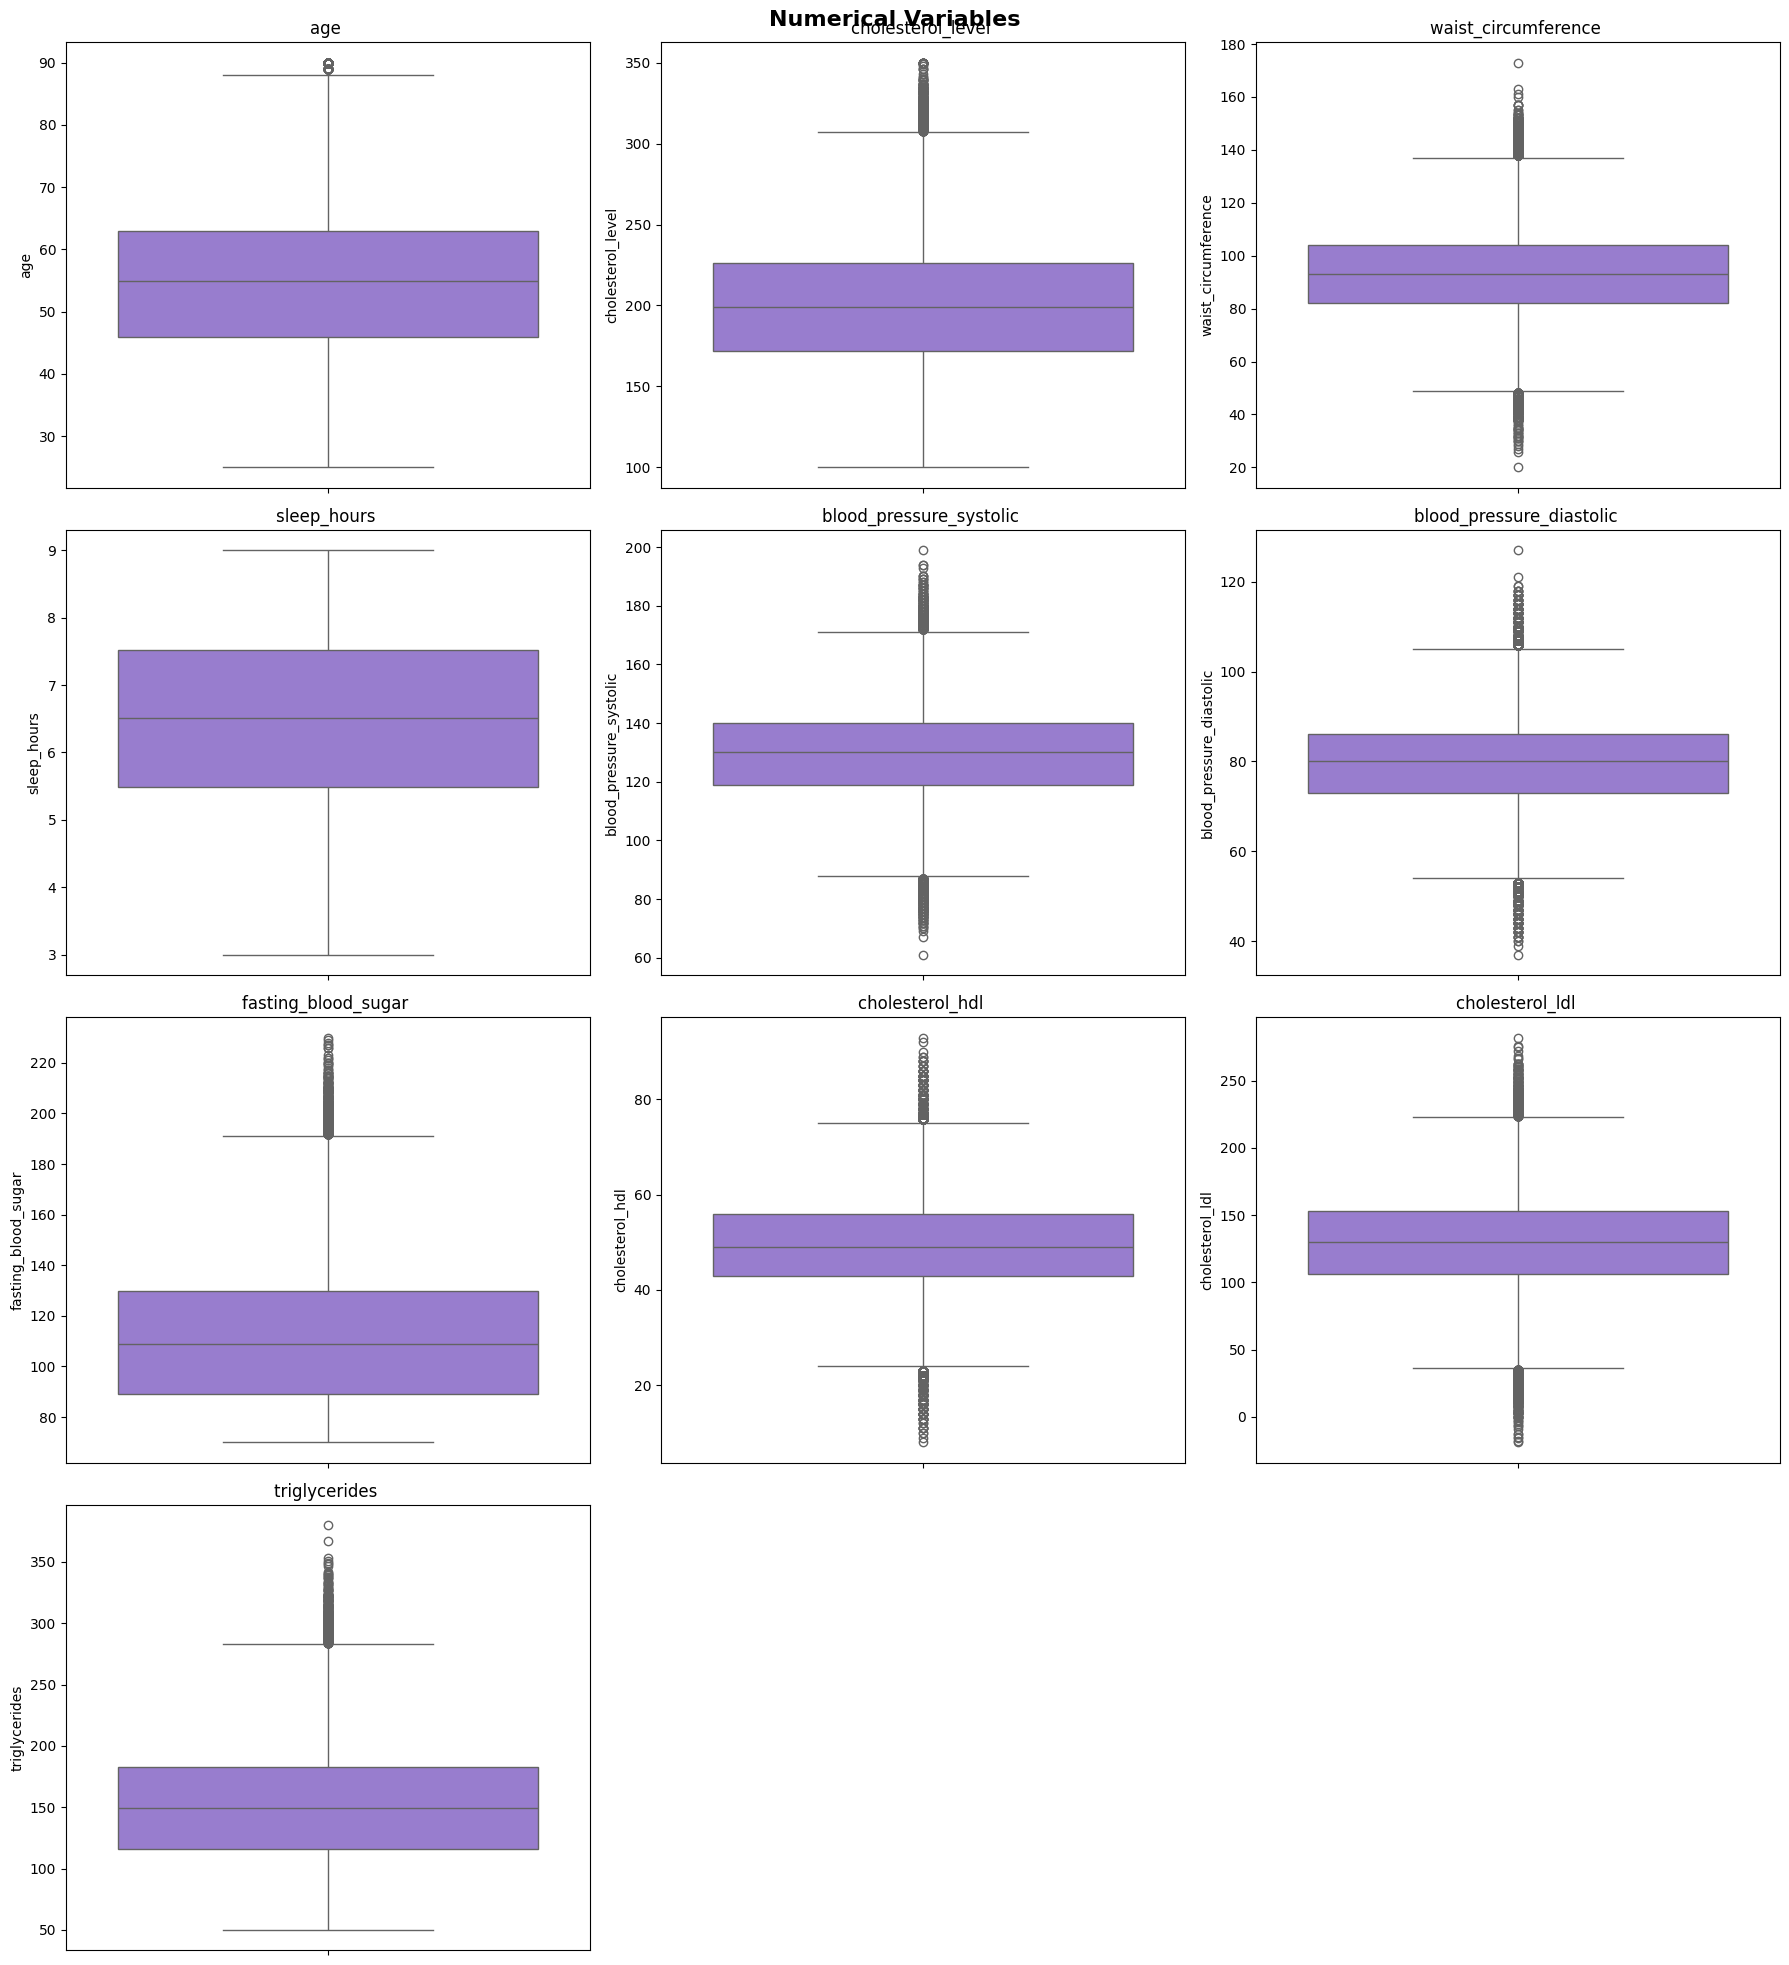

In [158]:
nums=data.select_dtypes(include=['int64','float64']).columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=data, y=col, ax=axes[i],color='#9370DB')
    axes[i].set_title(f'{col} ', fontsize=12)
    axes[i].set_ylabel(col)

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6598/3296544899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='heart_attack', y=col, ax=axes[i],
/tmp/ipykernel_6598/3296544899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='heart_attack', y=col, ax=axes[i],
/tmp/ipykernel_6598/3296544899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='heart_attack', y=col, ax=axes[i],
/tmp/ipykernel_6598/3296544899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

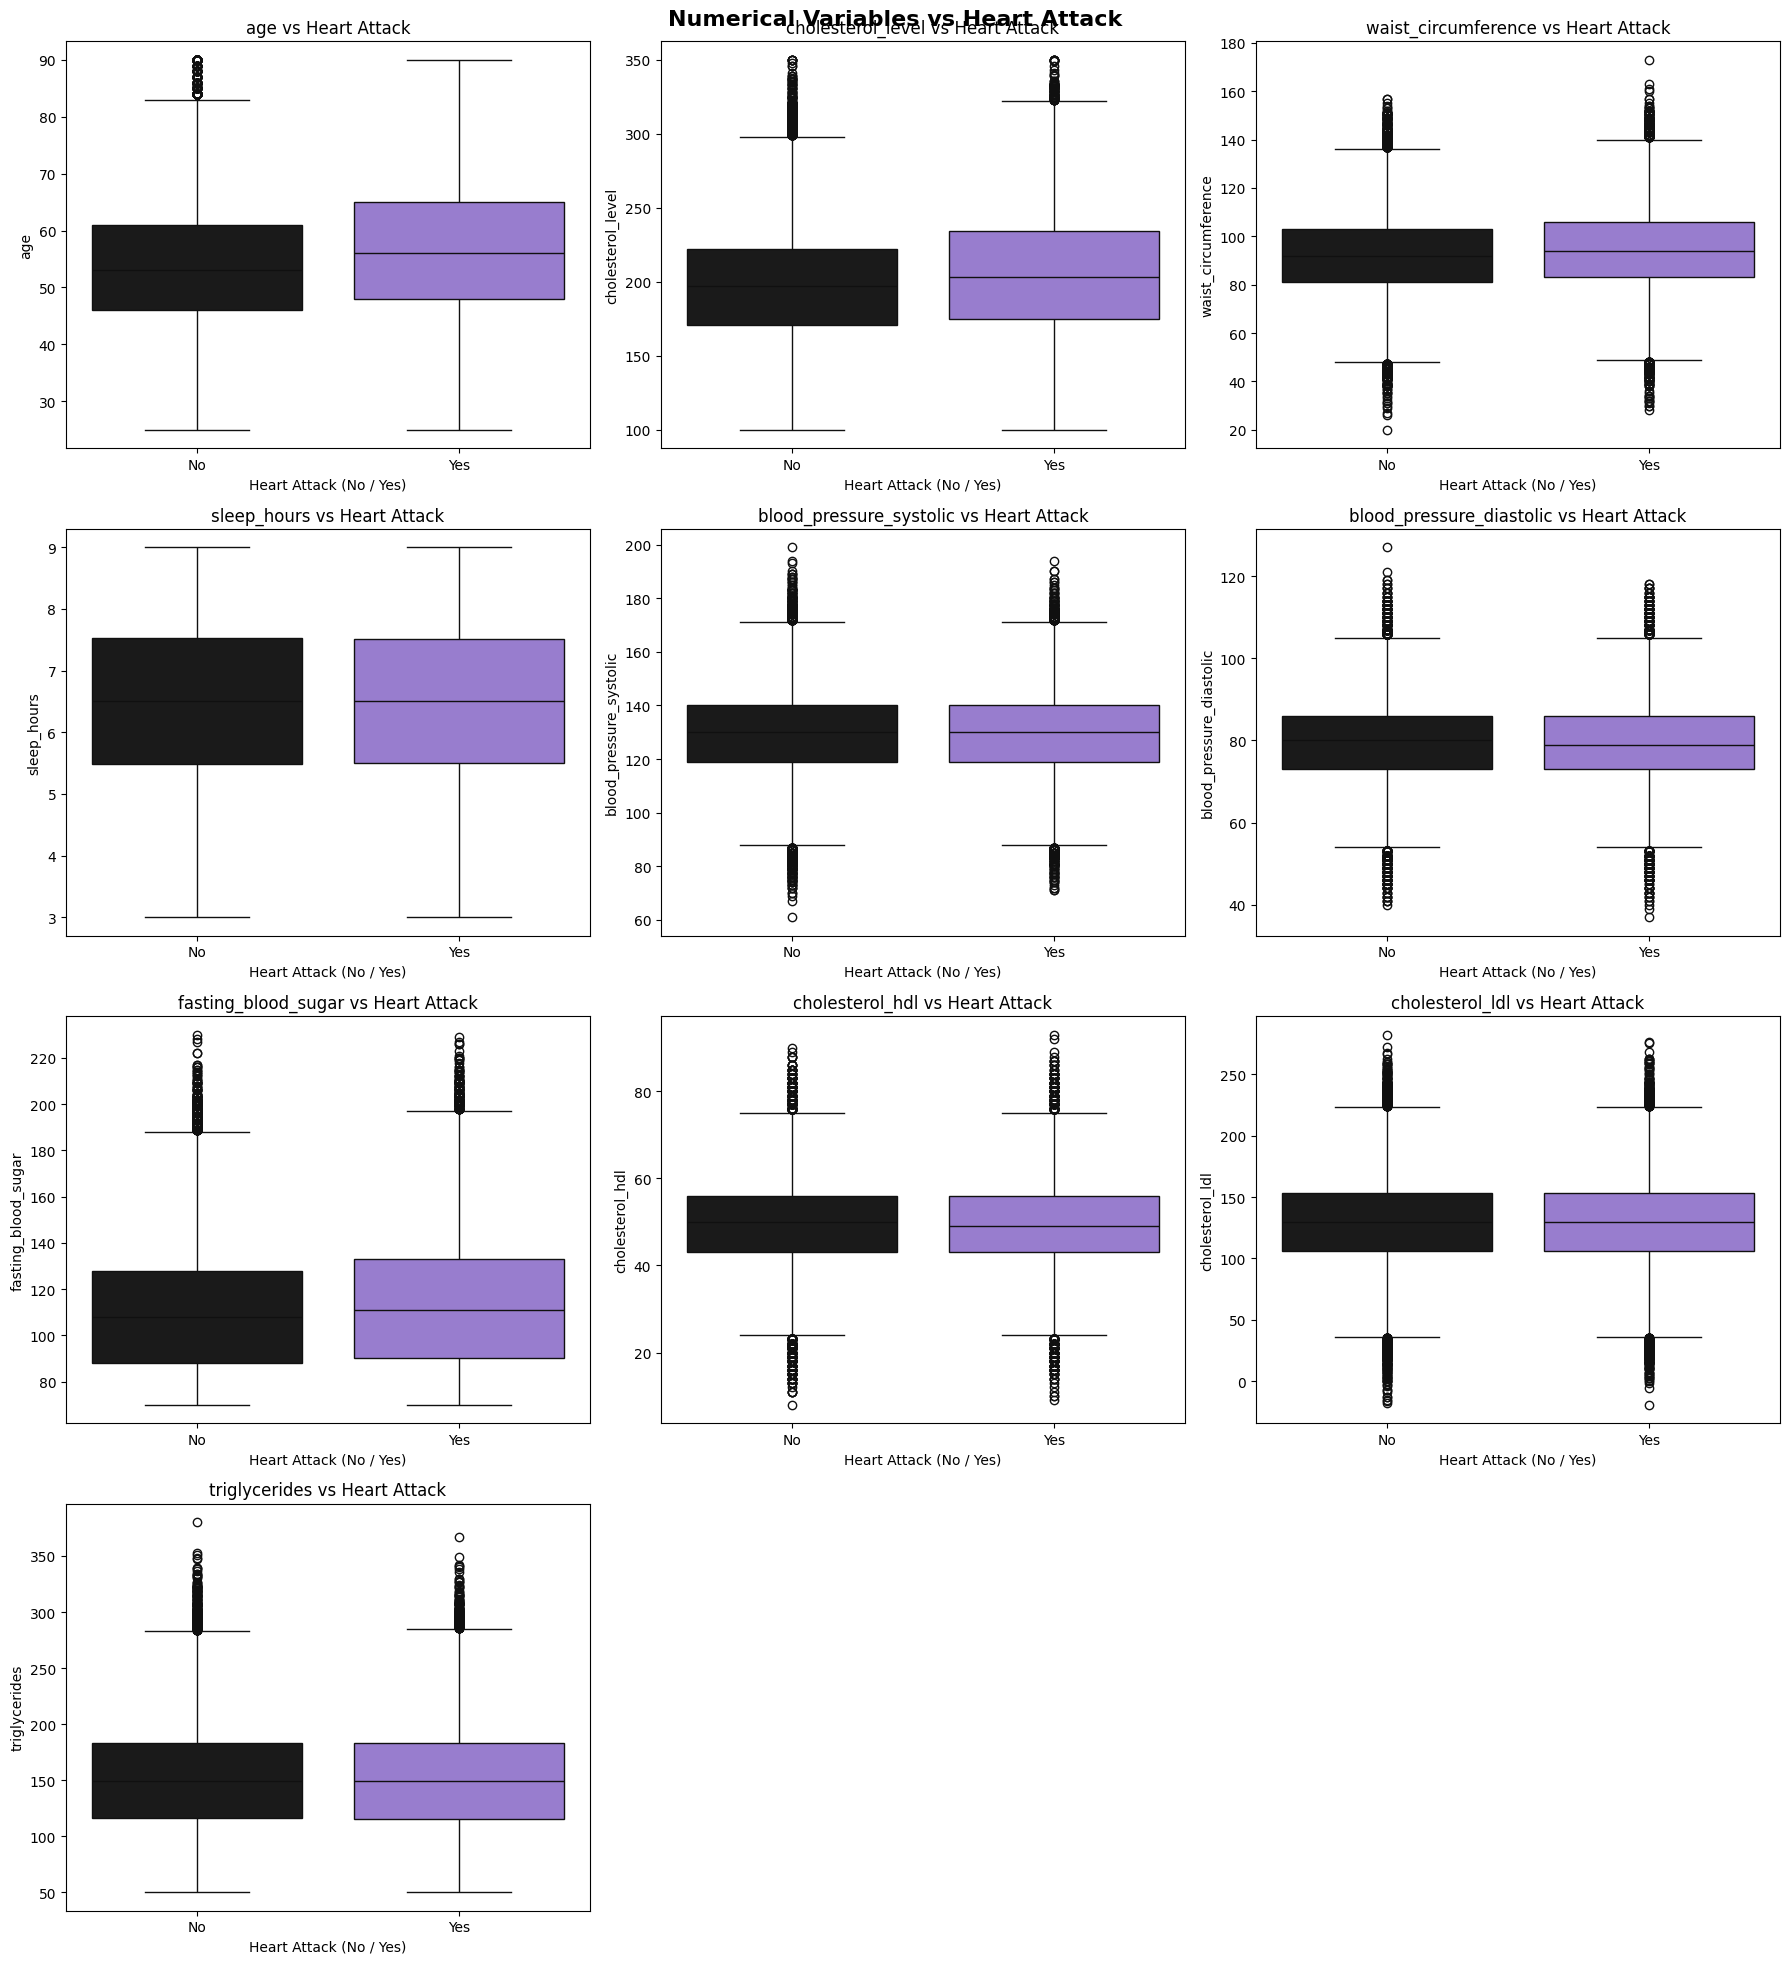

In [159]:
nums=data.select_dtypes(include=['int64','float64']).columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=data, x='heart_attack', y=col, ax=axes[i],
            palette={'No': '#1a1a1a', 'Yes': '#9370DB'})
    axes[i].set_title(f'{col} vs Heart Attack', fontsize=12)
    axes[i].set_xlabel('Heart Attack (No / Yes)')
    axes[i].set_ylabel(col)

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables vs Heart Attack', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[55, 56, 54, 57, 53, 52, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[198, 203, 196, 200, 197, 201, 194, 202, 193, ...",246,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[94, 91, 96, 93, 92, 97, 98, 95, 88, 89]",130,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


In [29]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr, pointbiserialr
import pandas as pd

y = data['heart_attack']#.map({'Yes': 1, 'No': 0})

cats = ['gender','income_level', 'region' ,'smoking_status',
        'dietary_habits','physical_activity',
        'air_pollution_exposure','stress_level','EKG_results']

nums = ['age', 'waist_circumference', 'cholesterol_level', 'sleep_hours',
        'blood_pressure_systolic', 'blood_pressure_diastolic',
        'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']

binary = [ 'hypertension', 'diabetes', 'obesity', 'family_history',
            'previous_heart_disease', 'medication_usage',
          'participated_in_free_screening']
data[binary] = data[binary].astype('int')
# ============================================================
#  ANOVA — categorical vs target
# ============================================================
cats_encoded = data[cats].apply(LabelEncoder().fit_transform)
f_values, p_values = f_classif(cats_encoded, y)

anova_df = pd.DataFrame({
    'Feature': cats,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print("=" * 50)
print("Categorical Features vs Heart Attack")
print("=" * 50)
print(anova_df.to_string(index=False))

# ============================================================
#  Pearson — numerical vs target
# ============================================================
rs, pvals = [], []

for col in nums:
    r, pval = pearsonr(data[col], y)
    rs.append(r)
    pvals.append(pval)

pearson_df = pd.DataFrame({
    'Feature': nums,
    'Pearson_r': rs,
    'P-Value': pvals
}).sort_values(by='Pearson_r', ascending=False)

print("\n" + "=" * 50)
print("Numerical Features vs Heart Attack")
print("=" * 50)
print(pearson_df.to_string(index=False))

# ============================================================
#  Point-Biserial — binary vs target
# ============================================================
rhos, pvals = [], []

for col in binary:
    r, pval = pointbiserialr(data[col], y)
    rhos.append(r)
    pvals.append(pval)

pb_df = pd.DataFrame({
    'Feature': binary,
    'PointBiserial_r': rhos,
    'P-Value': pvals
}).sort_values(by='PointBiserial_r', ascending=False)

print("\n" + "=" * 50)
print("Binary Features vs Heart Attack")
print("=" * 50)
print(pb_df.to_string(index=False))

Categorical Features vs Heart Attack
               Feature     F-Score  P-Value
        smoking_status 1667.751716 0.000000
                gender    7.863180 0.005046
                region    3.003582 0.083084
     physical_activity    1.528491 0.216342
        dietary_habits    1.211336 0.271071
          income_level    1.025145 0.311305
           EKG_results    0.484545 0.486373
air_pollution_exposure    0.462338 0.496535
          stress_level    0.056372 0.812325

Numerical Features vs Heart Attack
                 Feature  Pearson_r       P-Value
                     age   0.105112 1.226454e-214
       cholesterol_level   0.095563 1.331899e-177
     fasting_blood_sugar   0.073020 2.489876e-104
     waist_circumference   0.069525  9.751350e-95
             sleep_hours   0.001882  5.766952e-01
         cholesterol_ldl   0.000163  9.614134e-01
 blood_pressure_systolic  -0.001234  7.143015e-01
         cholesterol_hdl  -0.002954  3.809191e-01
blood_pressure_diastolic  -0.004796  

In [181]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[1, 0]",2,0,0.0,0
2,region,object,"[1, 0]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,object,"[0, 1]",2,0,0.0,0
5,diabetes,object,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 201, 197, 207, 195, 200, ...",247,0,0.0,0
7,obesity,object,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 93, 94, 96, 95, 92, 98, 89, 90, 97]",136,0,0.0,0
9,family_history,object,"[0, 1]",2,0,0.0,0


In [180]:
data=df.copy()